In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [5]:
train_dir = "data/training_set"
test_dir = "data/test_set"

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # Important for evaluation
)

Found 1608 images belonging to 2 classes.
Found 408 images belonging to 2 classes.


In [7]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1, activation='sigmoid'))  # Binary output

model.summary()


c:\Users\SwapnilShinde\OneDrive\Documents\Study Material\Sem 6\AML\Experiment Codes\aml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5062 - loss: 0.7462 - val_accuracy: 0.5417 - val_loss: 0.6804
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 317ms/step - accuracy: 0.5211 - loss: 0.6789 - val_accuracy: 0.5539 - val_loss: 0.6917
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 334ms/step - accuracy: 0.5734 - loss: 0.6769 - val_accuracy: 0.6446 - val_loss: 0.6541
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 319ms/step - accuracy: 0.6381 - loss: 0.6389 - val_accuracy: 0.6103 - val_loss: 0.6518
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 323ms/step - accuracy: 0.6592 - loss: 0.6165 - val_accuracy: 0.6912 - val_loss: 0.5909
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 325ms/step - accuracy: 0.6971 - loss: 0.5964 - val_accuracy: 0.7157 - val_loss: 0.5508
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 333ms/step - accuracy: 0.6685 - loss: 0.5979 - val_accuracy: 0.6642 - val_loss: 0.5868
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 319ms/step - accuracy: 0.6847 - loss: 0.5907 - val_accurac

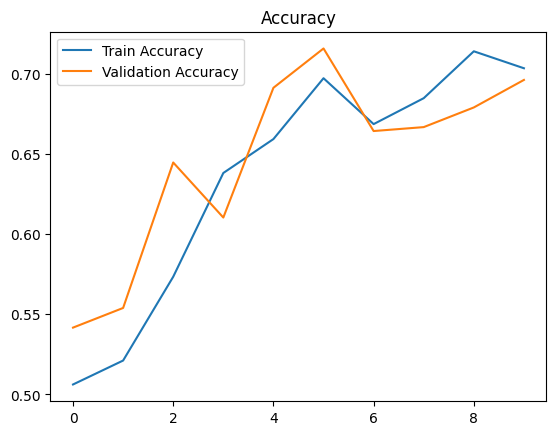

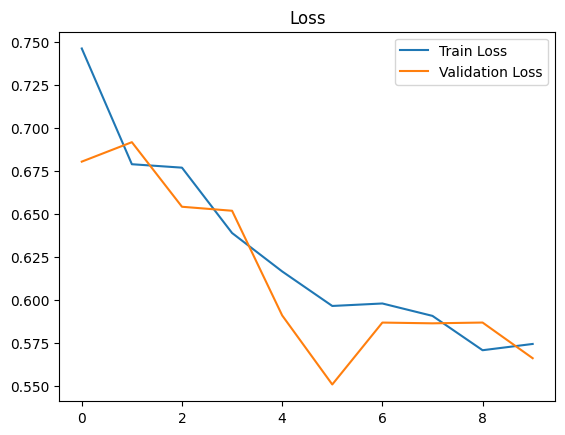

In [10]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [11]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6961 - loss: 0.5661
Test Accuracy: 0.6960784196853638


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


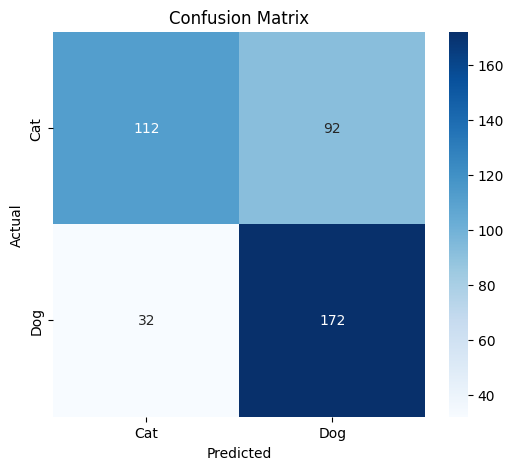

              precision    recall  f1-score   support

         Cat       0.78      0.55      0.64       204
         Dog       0.65      0.84      0.74       204

    accuracy                           0.70       408
   macro avg       0.71      0.70      0.69       408
weighted avg       0.71      0.70      0.69       408



In [12]:
# Predictions
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat','Dog'],
            yticklabels=['Cat','Dog'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_classes, target_names=['Cat','Dog']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Dog


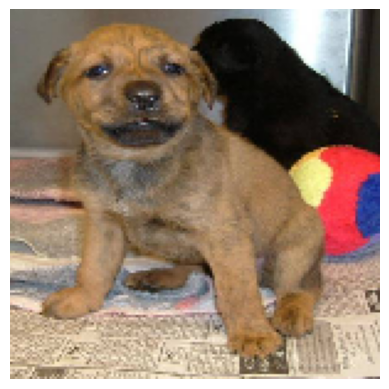

In [18]:
from tensorflow.keras.preprocessing import image

img_path = "test2.jpg"  # Put your image here

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Cat")
else:
    print("Dog")

plt.imshow(img)
plt.axis('off')
plt.show()